In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [41]:
df = pd.read_csv("HousingData.csv")

In [42]:
df.head()
df.isnull().sum()


CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


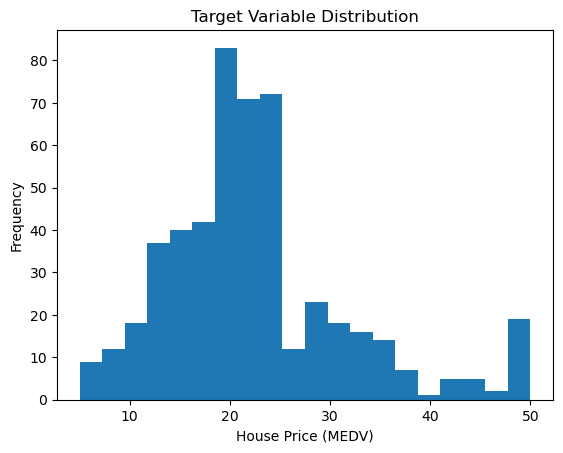

In [44]:
plt.hist(y, bins=20)
plt.xlabel("House Price (MEDV)")
plt.ylabel("Frequency")
plt.title("Target Variable Distribution")
plt.show()

In [45]:
df["CHAS"] = df["CHAS"].fillna(0)

df["CRIM"] = df["CRIM"].fillna(df["CRIM"].mean())
df["ZN"] = df["ZN"].fillna(df["ZN"].mean())
df["INDUS"] = df["INDUS"].fillna(df["INDUS"].mean())
df["AGE"] = df["AGE"].fillna(df["AGE"].mean())
df["LSTAT"] = df["LSTAT"].fillna(df["LSTAT"].mean())


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [47]:
X = df.drop("MEDV", axis = 1)
y = df["MEDV"]

In [48]:
X_train,X_test,y_train ,y_test = train_test_split(
    X, y , test_size=0.2 ,random_state=42
)

In [55]:
from sklearn.metrics import r2_score,mean_squared_error
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred =lr.predict(X_test)

In [57]:
print("MSE",mean_squared_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))

MSE 25.044653291454605
r2_score 0.6584840954311362


In [67]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(max_depth = 5)


In [68]:
dtr.fit(X_train,y_train)
y_pred_dtr = dtr.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred_dtr))
print("r2_score",r2_score(y_test,y_pred_dtr))

MSE 8.424792336478882
r2_score 0.8851171728306921


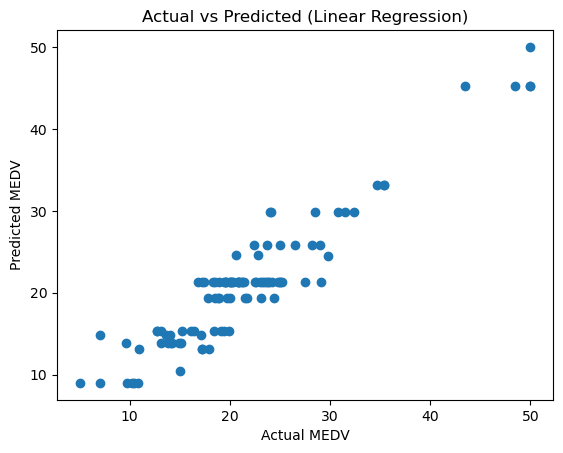

In [69]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred_dtr)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()